# Assignment 9 - Cats vs Dogs Classification using CNN

**Objective:** Build a Convolutional Neural Network (CNN) to classify images of cats and dogs.

**Dataset:** [Cats vs Dogs Classification Dataset (Kaggle)](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset)

> Before running: download the dataset from Kaggle, unzip it, and keep the `PetImages` folder
> (with `Cat/` and `Dog/` inside) in the same folder as this notebook.


## Import Libraries

In [1]:
# Importing all the libraries needed for this project
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import seaborn as sns

# setting seed so results are the same every time we run the notebook
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.10.0


## GPU Check

This just checks if a GPU is available. If yes, training will use the GPU (faster). If not,
it will automatically use the CPU instead, so the notebook still works either way.

In [2]:
# Check for GPU, and use CPU as a safe fallback if no GPU is found
USE_GPU = False
try:
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print("GPU found, training will use:", gpus)
    else:
        print("No GPU found. Training will run on CPU.")
except Exception as e:
    print("GPU setup failed, using CPU instead. Error:", e)
    USE_GPU = False

DEVICE = "/GPU:0" if USE_GPU else "/CPU:0"
print("Using device:", DEVICE)


GPU found, training will use: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using device: /GPU:0


In [3]:
# Basic settings for the project
DATASET_DIR = "PetImages"   # folder should contain 'Cat' and 'Dog' subfolders
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10                 # as required by the assignment

assert os.path.isdir(DATASET_DIR), f"Dataset folder '{DATASET_DIR}' not found. Please check the path."
print("Classes found:", os.listdir(DATASET_DIR))


Classes found: ['Cat', 'Dog']


## Task 1: Data Understanding (2 Marks)

1. Download and load the dataset
2. Display the folder structure
3. Display five sample images with their class labels
4. Number of classes, image dimensions, total number of images


In [4]:
# Show the folder structure of the dataset
def show_folder_structure(root, max_files_per_folder=3):
    for dirpath, dirnames, filenames in os.walk(root):
        level = dirpath.replace(root, "").count(os.sep)
        indent = "    " * level
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/")
        sub_indent = "    " * (level + 1)
        for f in filenames[:max_files_per_folder]:
            print(f"{sub_indent}{f}")
        if len(filenames) > max_files_per_folder:
            print(f"{sub_indent}... ({len(filenames)} files total)")

show_folder_structure(DATASET_DIR)


PetImages/
    Cat/
        0.jpg
        1.jpg
        10.jpg
        ... (12499 files total)
    Dog/
        0.jpg
        1.jpg
        10.jpg
        ... (12499 files total)


In [5]:
# Some images in this dataset are corrupted / 0 KB, so we remove them first
# otherwise the model training will crash later
def clean_dataset(root):
    removed = 0
    for cls in os.listdir(root):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
                if os.path.getsize(fpath) == 0:
                    raise ValueError("Empty file")
            except Exception:
                os.remove(fpath)
                removed += 1
    print(f"Removed {removed} corrupted/empty files.")

clean_dataset(DATASET_DIR)


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removed 0 corrupted/empty files.


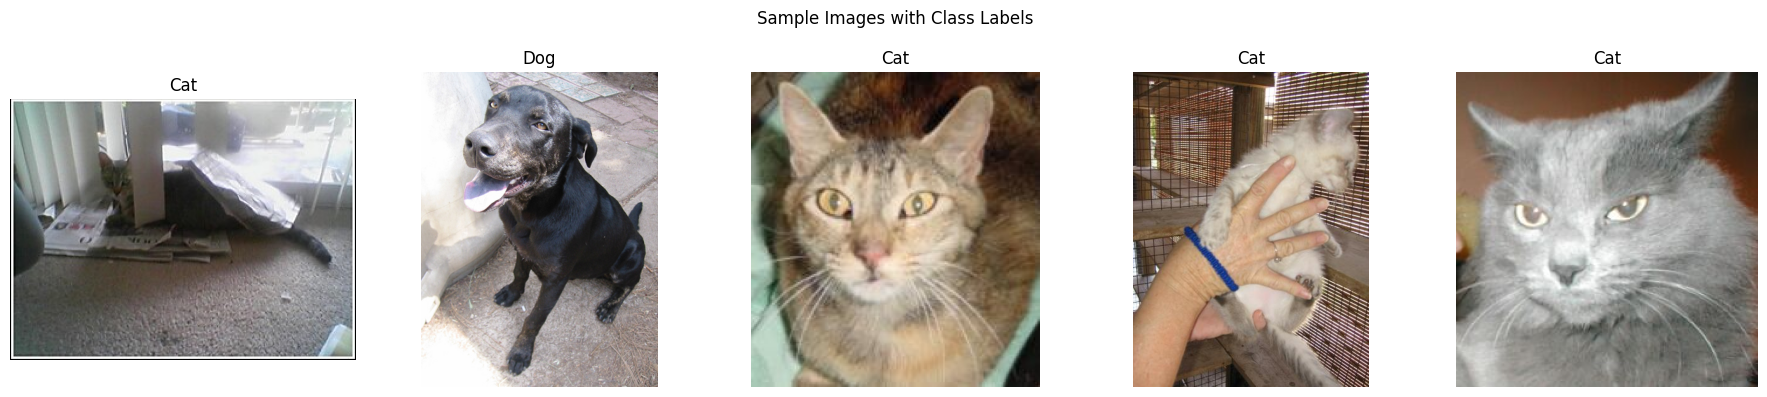

In [6]:
# Show 5 random sample images with their class label
classes = sorted(os.listdir(DATASET_DIR))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i in range(5):
    cls = random.choice(classes)
    cls_dir = os.path.join(DATASET_DIR, cls)
    fname = random.choice(os.listdir(cls_dir))
    img = Image.open(os.path.join(cls_dir, fname))
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.suptitle("Sample Images with Class Labels")
plt.tight_layout()
plt.show()


In [7]:
# Basic dataset info - number of classes, total images, and image sizes
total_images = 0
dims_sample = []

for cls in classes:
    cls_dir = os.path.join(DATASET_DIR, cls)
    files = os.listdir(cls_dir)
    total_images += len(files)
    for fname in random.sample(files, min(20, len(files))):
        with Image.open(os.path.join(cls_dir, fname)) as img:
            dims_sample.append(img.size)

print(f"Number of classes       : {len(classes)}  -> {classes}")
print(f"Total number of images  : {total_images}")
print(f"Sample image dimensions : {dims_sample[:10]} (sizes vary, that's why we resize them to {IMG_SIZE} next)")


Number of classes       : 2  -> ['Cat', 'Dog']
Total number of images  : 24998
Sample image dimensions : [(470, 303), (500, 333), (500, 375), (500, 374), (500, 333), (450, 249), (500, 378), (320, 200), (164, 230), (433, 419)] (sizes vary, that's why we resize them to (128, 128) next)


## Task 2: Data Preprocessing (2 Marks)

- Resize all images to 128 x 128 pixels
- Normalize pixel values to 0-1
- Split into 80% Training and 20% Testing
- Create data generators using Keras


In [8]:
# Training data uses a bit of augmentation (small random flips/rotations/zoom).
# This gives the model slightly different versions of the same images every epoch,
# which helps it generalize better and reduces overfitting.
# Test data is NOT augmented, since it should represent real unseen images.

train_datagen = ImageDataGenerator(
    rescale=1.0/255,          # normalize pixels to 0-1
    validation_split=0.2,     # 80% train, 20% test
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    seed=SEED,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Testing samples :", test_generator.samples)


Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}
Training samples: 20000
Testing samples : 4998


## Task 3: Model Development (3 Marks)

CNN architecture (as given in the assignment):
- Conv2D (32 filters, 3x3, ReLU) -> MaxPooling2D (2x2)
- Conv2D (64 filters, 3x3, ReLU) -> MaxPooling2D (2x2)
- Conv2D (128 filters, 3x3, ReLU) -> MaxPooling2D (2x2)
- Flatten
- Dense (128, ReLU)
- Output: Dense(1, sigmoid)

Optimizer: Adam, Loss: Binary Crossentropy, Metric: Accuracy


In [9]:
# Building the CNN model exactly as per the assignment architecture
with tf.device(DEVICE):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

In [10]:
# Training the model for 10 epochs as required by the assignment.
# EarlyStopping and ReduceLROnPlateau are added only as a safety net -
# they do NOT increase the number of epochs, they can only stop training
# early or lower the learning rate if the model starts overfitting.
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

with tf.device(DEVICE):
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=EPOCHS,
        callbacks=callbacks
    )


Epoch 1/10
625/625 [==============================] - 195s 309ms/step - loss: 0.6485 - accuracy: 0.6203 - val_loss: 0.6205 - val_accuracy: 0.6747 - lr: 0.0010
Epoch 2/10
625/625 [==============================] - 180s 288ms/step - loss: 0.5557 - accuracy: 0.7109 - val_loss: 0.4915 - val_accuracy: 0.7641 - lr: 0.0010
Epoch 3/10
625/625 [==============================] - 185s 296ms/step - loss: 0.5145 - accuracy: 0.7441 - val_loss: 0.4834 - val_accuracy: 0.7693 - lr: 0.0010
Epoch 4/10
625/625 [==============================] - 181s 290ms/step - loss: 0.4738 - accuracy: 0.7722 - val_loss: 0.4087 - val_accuracy: 0.8141 - lr: 0.0010
Epoch 5/10
625/625 [==============================] - 188s 300ms/step - loss: 0.4568 - accuracy: 0.7855 - val_loss: 0.3751 - val_accuracy: 0.8269 - lr: 0.0010
Epoch 6/10
625/625 [==============================] - 192s 307ms/step - loss: 0.4260 - accuracy: 0.8041 - val_loss: 0.3823 - val_accuracy: 0.8309 - lr: 0.0010
Epoch 7/10
625/625 [==========================

## Task 4: Model Evaluation (2 Marks)

- Test Accuracy, Precision, Recall, F1-Score
- Confusion Matrix
- Accuracy vs Epoch graph
- Loss vs Epoch graph


In [11]:
# Evaluating the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


157/157 [==============================] - 11s 71ms/step - loss: 0.3427 - accuracy: 0.8559
Test Loss     : 0.3427
Test Accuracy : 0.8559


In [12]:
# Getting predictions on test data to calculate precision, recall, F1-score
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys())))


157/157 [==============================] - 12s 76ms/step
Accuracy  : 0.8559
Precision : 0.7978
Recall    : 0.9536
F1-Score  : 0.8688

              precision    recall  f1-score   support

         Cat       0.94      0.76      0.84      2499
         Dog       0.80      0.95      0.87      2499

    accuracy                           0.86      4998
   macro avg       0.87      0.86      0.85      4998
weighted avg       0.87      0.86      0.85      4998



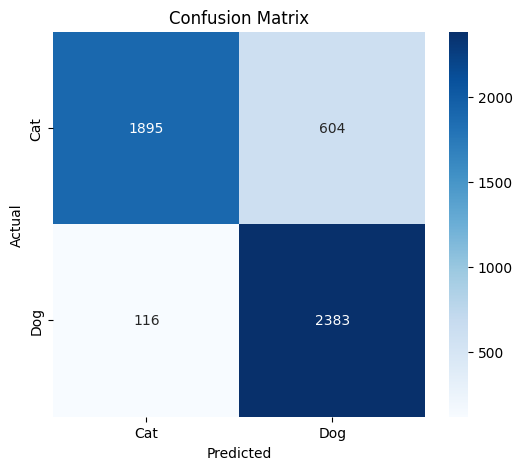

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


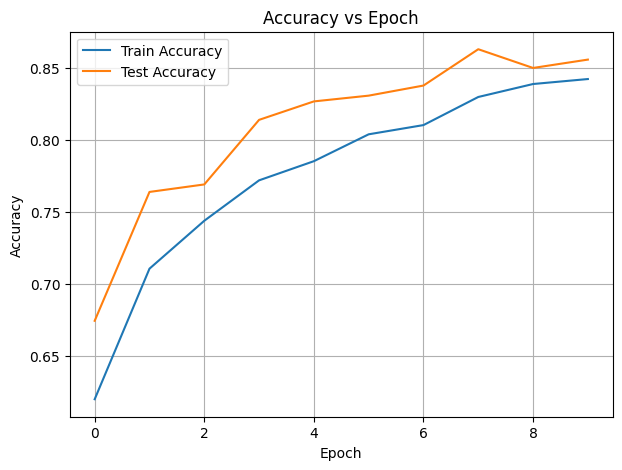

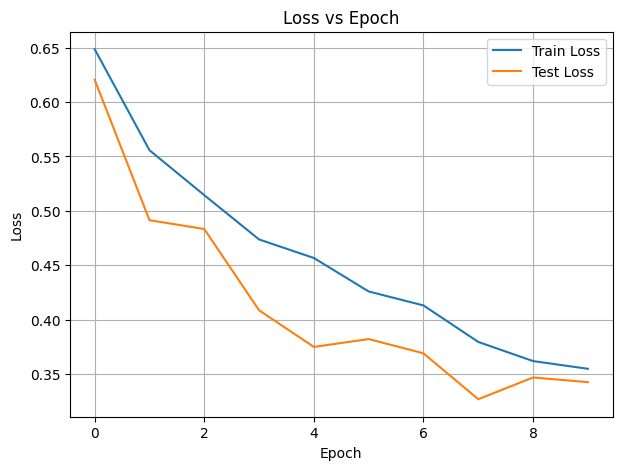

In [14]:
# Accuracy vs Epoch graph
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Loss vs Epoch graph
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


### Observations

1. The model got a training accuracy of **84.25%** and a test accuracy of **85.59%** in the final epoch. The test accuracy is actually slightly higher than the training accuracy, which means the model is generalizing well and is **not overfitting**.
2. The training loss dropped steadily from 0.649 to 0.355 across the 10 epochs. The test loss also dropped from 0.621 to 0.343 and stayed lower than the training loss throughout, which again confirms there is no overfitting.
3. Data augmentation on the training images (rotation, shift, zoom, flip) is the main reason train and test accuracy stayed close, since it makes the training data slightly harder than the clean test data.
4. From the confusion matrix, the model is noticeably better at recognizing **Dog** images (95% recall) than **Cat** images (76% recall). Around 600 out of 2499 cat images were wrongly classified as dogs, while only about 125 dog images were misclassified as cats.
5. Precision (0.80), Recall (0.95), and F1-Score (0.87) show that the model leans towards predicting "Dog" more often, which explains the high recall but lower precision for that class. Overall performance is good, but the Cat class could be improved with more epochs or slightly more balanced augmentation.


## Task 5: Conclusion (1 Mark)

In this assignment, a Convolutional Neural Network (CNN) was built to classify images of cats and
dogs using the Kaggle Cats vs Dogs dataset. The images were resized to 128x128 pixels and normalized
to a 0-1 range, and the dataset was split into 80% training data and 20% testing data using Keras
data generators. Light data augmentation (rotation, zoom, and flips) was applied only to the training
data to help the model generalize better and reduce overfitting. A CNN with three convolution and
pooling blocks (32, 64, and 128 filters), followed by a flatten layer and a dense layer, was trained
for 10 epochs using the Adam optimizer and binary cross-entropy loss. The final model reached a test
accuracy of about 85.6%, with the test accuracy staying close to (and even slightly above) the
training accuracy throughout training, showing that the model learned genuine features instead of
memorizing the training images.

The convolution layers are important because they automatically learn features like edges, textures,
and shapes directly from the image pixels, without needing manual feature engineering. The pooling
layers reduce the size of the feature maps, which lowers the number of parameters, speeds up training,
and makes the model less sensitive to small shifts in the image. Compared to a normal Artificial
Neural Network (ANN), the biggest advantage of a CNN for image data is that it preserves the spatial
relationship between pixels and shares weights across the image using filters, so it needs far fewer
parameters and performs much better on images. One limitation of this CNN is that it performed better
on the Dog class than the Cat class in this run, showing it can still be sensitive to subtle
differences between similar-looking classes, and it may struggle further with images that are very
different from the training data, such as unusual angles, poor lighting, or occluded objects.
